Detected kernel version 5.4.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.
100%|██████████| 15000/15000 [00:35<00:00, 419.09it/s]


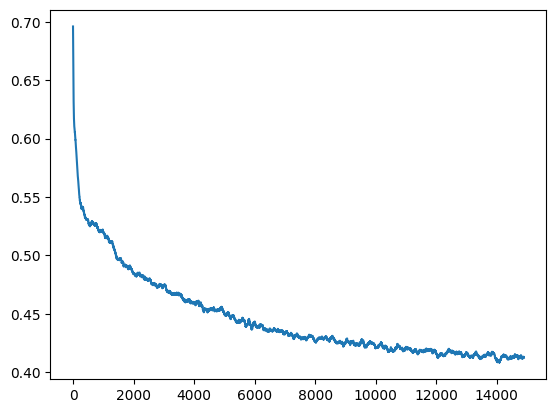

Detected kernel version 5.4.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


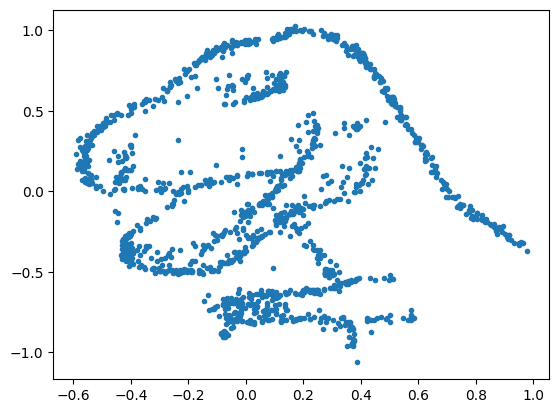

In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from smalldiffusion import (
    TimeInputMLP,
    ScheduleLogLinear,
    training_loop,
    samples,
    DatasaurusDozen,
    Swissroll,
)
from smalldiffusion.model import get_sigma_embeds


def plot_batch(batch):
    batch = batch.cpu().numpy()
    plt.scatter(batch[:, 0], batch[:, 1], marker=".")


def moving_average(x, w):
    return np.convolve(x, np.ones(w), "valid") / w


# Try replacing dataset with 'dino', 'bullseye', 'h_lines', 'x_shape', etc.
dataset = DatasaurusDozen(
    csv_file="minimal_diffusion/smalldiffusion/DatasaurusDozen.tsv",
    dataset="dino",
)
# Or use the SwissRoll dataset
# dataset = Swissroll(np.pi/2, 5*np.pi, 100)
loader = DataLoader(dataset, batch_size=2130)

schedule = ScheduleLogLinear(N=200, sigma_min=0.01, sigma_max=10)


sx, sy = get_sigma_embeds(len(schedule), schedule.sigmas).T


model = TimeInputMLP(hidden_dims=(16, 128, 128, 128, 128, 16))

trainer = training_loop(loader, model, schedule, epochs=15000, lr=1e-3)
losses = [ns.loss.item() for ns in trainer]

plt.plot(moving_average(losses, 100))
plt.show()

# For DDPM sampling, change to gam=1, mu=0.5
# For DDIM sampling, change to gam=1, mu=0
*xts, x0 = samples(model, schedule.sample_sigmas(20), batchsize=1500, gam=2, mu=0)
plot_batch(x0)

Detected kernel version 5.4.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


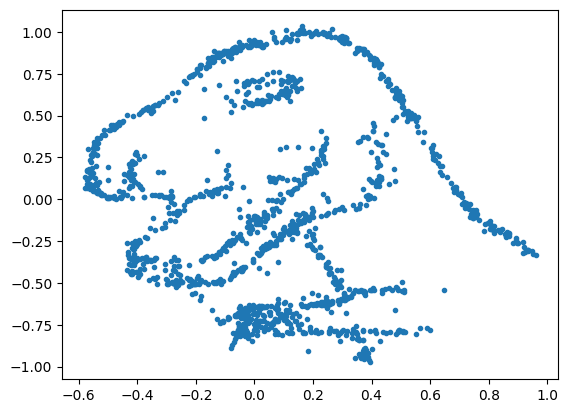

In [6]:
# For DDPM sampling, change to gam=1, mu=0.5
# For DDIM sampling, change to gam=1, mu=0
*xts, x0 = samples(model, schedule.sample_sigmas(20), batchsize=1500, gam=2, mu=0)
plot_batch(x0)